# (K-Nearest Neighbors) Regresor

In [7]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

ruta = r'C:\Users\jthow\iCloudDrive\Documents\3_Maestria_Estadistica_UNINORTE\3_Tercer_Semestre\Machine_Learning\tornados.csv.zip'  
df = pd.read_csv(ruta)  
df.isnull().sum()

om                  0
yr                  0
mo                  0
dy                  0
date                0
time                0
tz                  0
datetime_utc        0
st                  0
stf                 0
mag               756
inj                 0
fat                 0
loss            27170
slat                0
slon                0
elat                0
elon                0
len                 0
wid                 0
ns                  0
sn                  0
f1                  0
f2                  0
f3                  0
f4                  0
fc                  0
dtype: int64

In [8]:
df['loss'] = df['loss'].replace(0, pd.NA)
df['loss'] = df['loss'].interpolate(method='linear')
# Imputar los valores NaN con la media de la columna 'mag'
df['mag'] = df['mag'].fillna(df['mag'].mean())
df.isnull().sum()

om              0
yr              0
mo              0
dy              0
date            0
time            0
tz              0
datetime_utc    0
st              0
stf             0
mag             0
inj             0
fat             0
loss            0
slat            0
slon            0
elat            0
elon            0
len             0
wid             0
ns              0
sn              0
f1              0
f2              0
f3              0
f4              0
fc              0
dtype: int64

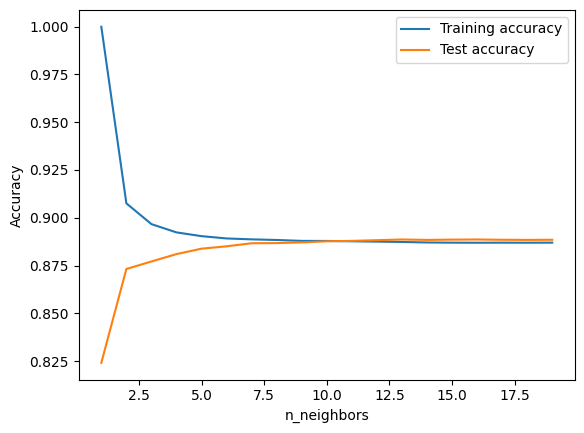

In [9]:
# Importar las bibliotecas necesarias
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

# Definir X y y (asegúrate de que ya tienes estas variables previamente definidas)
X = df[['mag', 'slat', 'slon', 'elat', 'elon', 'len', 'wid','f1', 'f2', 'f3', 'f4','loss']]
y = df['inj']

# Dividir los datos en conjunto de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Listas para almacenar la exactitud en entrenamiento y prueba
training_accuracy = []
test_accuracy = []

# Configuración de los vecinos
neighbors_settings = range(1, 20)

# Bucle para ajustar el modelo con diferentes números de vecinos
for n_neighbors in neighbors_settings:
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(X_train, y_train)
    training_accuracy.append(clf.score(X_train, y_train))
    test_accuracy.append(clf.score(X_test, y_test))

# Graficar los resultados
plt.plot(neighbors_settings, training_accuracy, label="Training accuracy")
plt.plot(neighbors_settings, test_accuracy, label="Test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend();


In [ ]:
pip install neighbors

In [12]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_log_error
import numpy as np

rmsle_val = []
best_rmsle = 1.0

for k in range(100):
    k = k + 1
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train) 
    y_pred = knn.predict(X_test)
    rmsle = np.sqrt(mean_squared_log_error(y_test, y_pred))
    
    if rmsle < best_rmsle:
        best_rmsle = rmsle
        best_k = k
    
    rmsle_val.append(rmsle)
    print('RMSLE value for k= ', k, 'is:', rmsle)

print(f"Best RMSLE: {best_rmsle}, Best k: {best_k}")

RMSLE value for k=  1 is: 0.6816286807006839
RMSLE value for k=  2 is: 0.6656252665729221
RMSLE value for k=  3 is: 0.6612691153244329
RMSLE value for k=  4 is: 0.6595793571815933
RMSLE value for k=  5 is: 0.6563323843698688
RMSLE value for k=  6 is: 0.6498963811099263
RMSLE value for k=  7 is: 0.6437372950411018
RMSLE value for k=  8 is: 0.646942874120371
RMSLE value for k=  9 is: 0.6451000344437993
RMSLE value for k=  10 is: 0.6429518628008284
RMSLE value for k=  11 is: 0.644002500319719
RMSLE value for k=  12 is: 0.6421971169006121
RMSLE value for k=  13 is: 0.6401345377242448
RMSLE value for k=  14 is: 0.6393388426512836
RMSLE value for k=  15 is: 0.6394217242835227
RMSLE value for k=  16 is: 0.6398721732291268
RMSLE value for k=  17 is: 0.6393148900307382
RMSLE value for k=  18 is: 0.6414916795239832
RMSLE value for k=  19 is: 0.6402653206808961
RMSLE value for k=  20 is: 0.6405620037193557
RMSLE value for k=  21 is: 0.6399051404927859
RMSLE value for k=  22 is: 0.6378065921347265

## Metricas (K-Nearest Neighbors) Regresor

In [13]:
# ------------------------
# Paso 1: Importar los paquetes necesarios
# ------------------------
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score, precision_score, recall_score, accuracy_score, f1_score, roc_auc_score
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera
from joblib import dump, load
from time import time

# ------------------------
# Paso 2: Cargar los datos
# ------------------------
# Asegúrate de que esta parte sea correcta para tu caso
# X_train, X_test, y_train, y_test = ...

# ------------------------
# Paso 3: Definir el pipeline y el grid de hiperparámetros
# ------------------------
# Definir el pipeline con un escalador y el modelo KNN
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),  # Normalización de los datos
    ('knn', KNeighborsClassifier())  # Modelo KNN
])

# Definir el grid de hiperparámetros para KNN
param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9],  # Número de vecinos
    'knn__weights': ['uniform', 'distance']  # Tipo de peso
}

# ------------------------
# Paso 4: Entrenar el modelo KNN con GridSearchCV
# ------------------------
# Crear el objeto GridSearchCV
grid_knn = GridSearchCV(pipe_knn, param_grid_knn, cv=5, n_jobs=-1, scoring='accuracy')

# Medir el tiempo de entrenamiento
start_time = time()
grid_knn.fit(X_train, y_train)
training_time_knn = time() - start_time

# Guardar el modelo entrenado
dump(grid_knn, 'grid_knn.joblib')

# ------------------------
# Paso 5: Hacer predicciones con el mejor modelo
# ------------------------
y_pred_knn = grid_knn.best_estimator_.predict(X_test)
y_pred_proba_knn = grid_knn.best_estimator_.predict_proba(X_test)[:, 1]

# ------------------------
# Paso 6: Calcular las métricas del modelo
# ------------------------

# Métricas originales
mape_knn = mean_absolute_percentage_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)

# Ljung-Box p-value
lb_p_value_knn = acorr_ljungbox(y_test - y_pred_knn, lags=[10], return_df=True)['lb_pvalue'].iloc[0]

# Jarque-Bera p-value
jb_p_value_knn = jarque_bera(y_test - y_pred_knn)[1]


# ------------------------
# Paso 7: Crear DataFrame con los resultados
# ------------------------
resultados_knn = pd.DataFrame({
    'Modelo': ['KNN optimizado (GridSearchCV)'],
    'MAPE': [f"{mape_knn:.2f}"],
    'RMSE': [f"{rmse_knn:.2f}"],
    'R Cuadrado': [f"{r2_knn:.2f}"],
    'Ljung-Box p-value': [f"{lb_p_value_knn:.2f}" if 'lb_p_value_knn' in locals() else None],
    'Jarque-Bera p-value': [f"{jb_p_value_knn:.2f}"],
    'CPU time (s)': [round(training_time_knn, 2)]
})

# ------------------------
# Paso 8: Mostrar los resultados
# ------------------------
print("Métricas para el modelo KNN:")
display(resultados_knn)

Métricas para el modelo KNN:


,Modelo,MAPE,RMSE,R Cuadrado,Ljung-Box p-value,Jarque-Bera p-value,CPU time (s)
0,KNN optimizado (GridSearchCV),28846114506776.71,22.97,0.00,0.83,0.00,189.61
